In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from IPython.display import Image,display
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.checkpoint.memory import MemorySaver
from langchain_tavily import TavilySearch
from langgraph.graph.message import add_messages

In [37]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [91]:
llm=init_chat_model(model="groq:openai/gpt-oss-120b")
tool=TavilySearch(max_results=2)
agent=llm.bind_tools([tool])
config={'configurable':{"thread_id":1}}

In [87]:
def tool_calling_llm(state:State):
    return {"messages":[agent.invoke(state['messages'])]}

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm',tools_condition)
builder.add_edge('tools',"tool_calling_llm")

graph=builder.compile(checkpointer =MemorySaver())

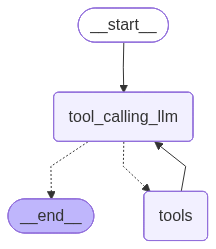

In [88]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [92]:
response=graph.invoke({'messages':'give me recent ai news'},config=config)
response['messages'][-1].content


'**Recent AI News (May\u202f–\u202fJune\u202f2024\u202f/\u202fMay\u202f2026 – the most current coverage available)**  \n\nBelow is a quick‑read roundup of the biggest AI‑related stories that have surfaced in the last few weeks, grouped by theme.  All items are linked to the source where the detail was found.\n\n---\n\n### 1️⃣ Model & Platform Releases  \n\n| Date | Headline | Why it matters |\n|------|----------|----------------|\n| **May\u202f27\u202f2026** – DeepMind CEO Demis\u202fHassabis says today’s AI agents are a “practice run” for AGI. | Signals a shift toward more aggressive timelines for artificial‑general‑intelligence and frames current agentic systems as a societal stress‑test. | <https://michaelparekh.substack.com/p/ai-google-deepmind-ceo-demis-hassabis> |\n| **May\u202f20\u202f2026** – OpenAI ships **GPT‑5.5 “Spud”** with new agentic capabilities and a higher per‑token price. | First major price‑increase launch in two years; adds tool‑use and planning functions that push

In [93]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

give me recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_0f7b1d0f-678a-4261-bead-d2ceefc1d0bd)
 Call ID: fc_0f7b1d0f-678a-4261-bead-d2ceefc1d0bd
  Args:
    query: latest AI news 2024 May
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2024 May", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "title": "The Latest AI News and Breakthroughs That Matter Most", "content": "Now, let's explore the latest news for AI advancements and developments from March to May 2026. AMD Pioneers AI Innovation with 2nm EPYC Processors. Date: May", "score": 0.9997749, "raw_content": null}, {"url": "https://www.facebook.com/groups/95